## Linear Classifier in TensorFlow 
Using Low Level API in Eager Execution mode

### Load tensorflow

In [1]:
import tensorflow as tf

### Collect Data

In [2]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv('prices.csv')

### Check all columns in the dataset

In [12]:
df.shape

(851264, 7)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
date      851264 non-null object
symbol    851264 non-null object
open      851264 non-null float64
close     851264 non-null float64
low       851264 non-null float64
high      851264 non-null float64
volume    851264 non-null float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB


### Drop columns `date` and  `symbol`

In [14]:
df= df.drop(["date","symbol"],axis=1)

In [15]:
df.head(20)

,open,close,low,high,volume
0,123.430000,125.839996,122.309998,126.250000,2163600.0
1,125.239998,119.980003,119.940002,125.540001,2386400.0
2,116.379997,114.949997,114.930000,119.739998,2489500.0
3,115.480003,116.620003,113.500000,117.440002,2006300.0
4,117.010002,114.970001,114.089996,117.330002,1408600.0
5,115.510002,115.550003,114.500000,116.059998,1098000.0
6,116.459999,112.849998,112.589996,117.070000,949600.0
7,113.510002,114.379997,110.050003,115.029999,785300.0
8,113.330002,112.529999,111.919998,114.879997,1093700.0
9,113.660004,110.379997,109.870003,115.870003,1523500.0


### Consider only first 1000 rows in the dataset for building feature set and target set
Target 'Volume' has very high values. Divide 'Volume' by 1000,000

In [16]:
df = df.head(1000)

In [17]:
df["volume"]= df["volume"]/1000000

In [19]:
df["volume"].head(10)

0    2.1636
1    2.3864
2    2.4895
3    2.0063
4    1.4086
5    1.0980
6    0.9496
7    0.7853
8    1.0937
9    1.5235
Name: volume, dtype: float64

### Divide the data into train and test sets

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
# split into 66% for train and 33% for test
X = df.drop( ["volume"] ,axis=1).values
y = df["volume"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=7)

#### Convert Training and Test Data to numpy float32 arrays


In [23]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

### Normalize the data
You can use Normalizer from sklearn.preprocessing

In [24]:
from sklearn.preprocessing import normalize
X_train = normalize(X_train)
X_test = normalize(X_test)

## Building the Model in tensorflow

1.Define Weights and Bias, use tf.zeros to initialize weights and Bias

In [25]:
#Input features
x = tf.placeholder(shape=[None,4],dtype=tf.float32, name='x-input')
#Normalize the data
x_n = tf.nn.l2_normalize(x,1)
#Actual Prices
y_ = tf.placeholder(shape=[None],dtype=tf.float32, name='y-input')
W = tf.Variable(tf.zeros(shape=[4,1]), name="Weights")
b = tf.Variable(tf.zeros(shape=[1]),name="Bias")
y = tf.add(tf.matmul(x_n,W),b,name='output')

Instructions for updating:
Colocations handled automatically by placer.


2.Define a function to calculate prediction

In [26]:
def predict1(x,w,b):
    return tf.add(tf.matmul(x,w),b)

3.Loss (Cost) Function [Mean square error]

In [27]:
mse = tf.reduce_mean(tf.square(y-y_),name='mse')

4.Function to train the Model

1.   Record all the mathematical steps to calculate Loss
2.   Calculate Gradients of Loss w.r.t weights and bias
3.   Update Weights and Bias based on gradients and learning rate to minimize loss

In [28]:
train_op = tf.train.GradientDescentOptimizer(0.03).minimize(mse)

## Train the model for 100 epochs 
1. Observe the training loss at every iteration
2. Observe Train loss at every 5th iteration

In [29]:
#Lets start graph Execution
sess = tf.Session()

# variables need to be initialized before we can use them
sess.run(tf.global_variables_initializer())

#how many times data need to be shown to model
training_epochs = 100

In [30]:
for epoch in range(training_epochs):

    y, train_loss = sess.run([train_op,mse],feed_dict={x:X_train, y_:y_train})
    
    if epoch % 5 == 0:
        print ('Training loss at step: ', epoch, ' is ', train_loss)

Training loss at step:  0  is  317.99866
Training loss at step:  5  is  294.53235
Training loss at step:  10  is  287.99673
Training loss at step:  15  is  286.17654
Training loss at step:  20  is  285.66968
Training loss at step:  25  is  285.52847
Training loss at step:  30  is  285.48898
Training loss at step:  35  is  285.47806
Training loss at step:  40  is  285.4751
Training loss at step:  45  is  285.47424
Training loss at step:  50  is  285.47406
Training loss at step:  55  is  285.47394
Training loss at step:  60  is  285.4739
Training loss at step:  65  is  285.47385
Training loss at step:  70  is  285.47385
Training loss at step:  75  is  285.474
Training loss at step:  80  is  285.47397
Training loss at step:  85  is  285.4739
Training loss at step:  90  is  285.4739
Training loss at step:  95  is  285.4739


### Get the shapes and values of W and b

In [31]:
print(sess.run(W)) 

[[1.4239742]
 [1.4288251]
 [1.4091965]
 [1.4408499]]


In [32]:
print(sess.run(b)) 

[2.851581]


### Model Prediction on 1st Examples in Test Dataset

In [33]:
y_pred1 =predict1(X_test[0:1],W,b)
sess.run(y_pred1)
#print("Model Prediction on 1st Examples in Test Dataset",sess.run(y_pred))

array([[5.7029133]], dtype=float32)

In [34]:
mse1 = sess.run([mse],feed_dict={x:X_test, y_:y_test})

In [35]:
print(mse1)

[54.331493]


## Classification using tf.Keras

In this exercise, we will build a Deep Neural Network using tf.Keras. We will use Iris Dataset for this exercise.

### Load the given Iris data using pandas (Iris.csv)

In [36]:
 df_ir= pd.read_csv('11_Iris.csv')

In [37]:
df_ir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
Id               150 non-null int64
SepalLengthCm    150 non-null float64
SepalWidthCm     150 non-null float64
PetalLengthCm    150 non-null float64
PetalWidthCm     150 non-null float64
Species          150 non-null object
dtypes: float64(4), int64(1), object(1)
memory usage: 7.1+ KB


### Target set has different categories. So, Label encode them. And convert into one-hot vectors using get_dummies in pandas.

In [38]:
df_ir.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [39]:
df_ir =df_ir.drop(["Id"],axis=1)

In [40]:
X= df_ir.drop(["Species"],axis=1)
y= df_ir["Species"]

In [41]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

In [42]:
# One hot encoding
enc = OneHotEncoder()
Y = enc.fit_transform(y[:, np.newaxis]).toarray()

In [43]:
cols = ["Iris-Setosa","Iris-Versicolor","Iris-Virginica"]
y= pd.DataFrame(Y,columns=cols)

In [46]:
# Scale data to have mean 0 and variance 1 
# which is importance for convergence of the neural network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data set into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=7)

### Splitting the data into feature set and target set

###  Building Model in tf.keras

Build a Linear Classifier model  <br>
1.  Use Dense Layer  with input shape of 4 (according to the feature set) and number of outputs set to 3<br> 
2. Apply Softmax on Dense Layer outputs <br>
3. Use SGD as Optimizer
4. Use categorical_crossentropy as loss function 

In [47]:
from keras.models import Sequential
from keras.layers import Dense

Using TensorFlow backend.


In [48]:
model = Sequential()
model.add(Dense(3, input_dim=4, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='sgd')

### Model Training 

In [49]:
# Fit the model
hist=model.fit(X_train, y_train, epochs=150, batch_size=5)

Instructions for updating:
Use tf.cast instead.
Epoch 1/150
105/105 [==============================] - 0s 2ms/step - loss: 1.4409
Epoch 2/150
105/105 [==============================] - 0s 142us/step - loss: 1.1428
Epoch 3/150
105/105 [==============================] - 0s 219us/step - loss: 0.9254
Epoch 4/150
105/105 [==============================] - 0s 237us/step - loss: 0.7770
Epoch 5/150
105/105 [==============================] - 0s 256us/step - loss: 0.6762
Epoch 6/150
105/105 [==============================] - 0s 199us/step - loss: 0.6074
Epoch 7/150
105/105 [==============================] - 0s 257us/step - loss: 0.5569
Epoch 8/150
105/105 [==============================] - 0s 209us/step - loss: 0.5197
Epoch 9/150
105/105 [==============================] - 0s 285us/step - loss: 0.4904
Epoch 10/150
105/105 [==============================] - 0s 247us/step - loss: 0.4674
Epoch 11/150
105/105 [==============================] - 0s 199us/step - loss: 0.4484
Epoch 12/150
105/105 [======

105/105 [==============================] - 0s 275us/step - loss: 0.2159
Epoch 95/150
105/105 [==============================] - 0s 247us/step - loss: 0.2151
Epoch 96/150
105/105 [==============================] - 0s 332us/step - loss: 0.2142
Epoch 97/150
105/105 [==============================] - 0s 199us/step - loss: 0.2134
Epoch 98/150
105/105 [==============================] - 0s 342us/step - loss: 0.2125
Epoch 99/150
105/105 [==============================] - 0s 304us/step - loss: 0.2117
Epoch 100/150
105/105 [==============================] - 0s 247us/step - loss: 0.2109
Epoch 101/150
105/105 [==============================] - 0s 351us/step - loss: 0.2100
Epoch 102/150
105/105 [==============================] - 0s 237us/step - loss: 0.2094
Epoch 103/150
105/105 [==============================] - 0s 180us/step - loss: 0.2084
Epoch 104/150
105/105 [==============================] - 0s 313us/step - loss: 0.2077
Epoch 105/150
105/105 [==============================] - 0s 209us/step - 

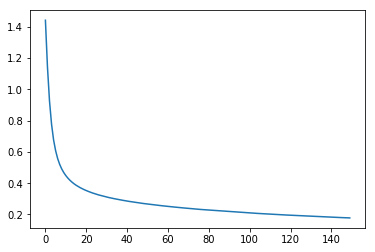

In [50]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])

### Model Prediction

In [51]:
model.predict(X_test)

array([[1.10686822e-02, 3.04284126e-01, 6.84647202e-01],
       [7.83319250e-02, 6.00405574e-01, 3.21262479e-01],
       [9.92140353e-01, 7.81596173e-03, 4.37673662e-05],
       [6.44719824e-02, 5.90562582e-01, 3.44965428e-01],
       [1.46937687e-02, 7.35929132e-01, 2.49377146e-01],
       [4.75514919e-01, 5.24186194e-01, 2.98897357e-04],
       [1.32632870e-02, 3.97652268e-01, 5.89084387e-01],
       [3.63847688e-02, 8.29042435e-01, 1.34572804e-01],
       [9.85952497e-01, 1.39965275e-02, 5.09842685e-05],
       [5.70649467e-02, 4.34433132e-01, 5.08501947e-01],
       [6.42058020e-03, 3.07348788e-01, 6.86230600e-01],
       [1.32765874e-01, 2.99866080e-01, 5.67368031e-01],
       [9.99245524e-01, 7.46949227e-04, 7.55715382e-06],
       [2.44915107e-04, 6.27291296e-03, 9.93482172e-01],
       [9.84212816e-01, 1.57250725e-02, 6.21287109e-05],
       [3.28558795e-02, 2.57478446e-01, 7.09665716e-01],
       [2.85135466e-04, 3.47192258e-01, 6.52522624e-01],
       [4.49733762e-03, 1.98399

In [52]:
scores = model.evaluate(X_test, y_test)
print("score=", scores)

45/45 [==============================] - 0s 820us/step
score= 0.36087501909997727


### Save the Model

In [53]:
model.save("11iris.h5")

### Build and Train a Deep Neural network with 2 hidden layer  - Optional - For Practice

Does it perform better than Linear Classifier? What could be the reason for difference in performance?